In [7]:
import numpy as np
from glob import glob
import os
import skimage as sk
from skan import draw
from skan.csr import skeleton_to_csgraph
from skan import Skeleton, summarize
import napari
import matplotlib.pyplot as plt
import pandas as pd

## Create Skeletons!

In [2]:
cropped_imgs = sorted(glob("cropped_imgs/*.tif"))
cropped_imgs = list(map(sk.io.imread,cropped_imgs))
skeletons = sorted(glob('skeletons/*.tif'))
skeletons = list(map(sk.io.imread,skeletons))

In [22]:
equalized_hist = [sk.exposure.equalize_adapthist(img) for img in cropped_imgs]

c:\ProgramData\anaconda3\envs\skan\lib\site-packages\skimage\util\dtype.py:527: UserWarning: Downcasting uint32 to uint16 without scaling because max value 9110 fits in uint16
  return _convert(image, np.uint16, force_copy)
c:\ProgramData\anaconda3\envs\skan\lib\site-packages\skimage\util\dtype.py:527: UserWarning: Downcasting uint32 to uint16 without scaling because max value 7979 fits in uint16
  return _convert(image, np.uint16, force_copy)
c:\ProgramData\anaconda3\envs\skan\lib\site-packages\skimage\util\dtype.py:527: UserWarning: Downcasting uint32 to uint16 without scaling because max value 8129 fits in uint16
  return _convert(image, np.uint16, force_copy)
c:\ProgramData\anaconda3\envs\skan\lib\site-packages\skimage\util\dtype.py:527: UserWarning: Downcasting uint32 to uint16 without scaling because max value 14052 fits in uint16
  return _convert(image, np.uint16, force_copy)
c:\ProgramData\anaconda3\envs\skan\lib\site-packages\skimage\util\dtype.py:527: UserWarning: Downcastin

In [ ]:
threshold_yen =[img > sk.filters.threshold_yen(img) for img in equalized_hist]

In [ ]:
filtered_objects = [sk.morphology.remove_small_objects(img,min_size=30) for img in threshold_yen]

In [ ]:
labeled_objects = [sk.morphology.label(img) for img in filtered_objects]

In [ ]:
viewer = napari.view_image(labeled_objects[0])

In [ ]:
skeletons = [sk.morphology.skeletonize(img) for img in labeled_objects]

In [ ]:
files = sorted(glob("cropped_imgs/*.tif"))
path = "skeletons"
for i in range(len(skeletons)):
    name = os.path.basename(files[i])
    sk.io.imsave(os.path.join(path,name[:-4]+'_skeleton.tif'),skeletons[i])


In [ ]:
i=2
print("ax"+str(i))

In [ ]:
save_path = 'skeletons'
for i in range(len(skeletons)):
    name = os.path.basename(files[i])
    fig,ax=plt.subplots()
    draw.overlay_skeleton_2d(equalized_hist[i],skeletons[i],image_cmap='Greys_r',dilate=1,axes=ax)
    fig.set_tight_layout(tight=True)
    plt.show(block=True)
    fig.savefig(os.path.join(save_path,name[:-4]+'_skeleton_overlay.png'),dpi=300)


In [ ]:
fig, ax = plt.subplots(6,3,figsize=(9,11))
c=0
for row in range(6):
    for col in range(3):
        draw.overlay_skeleton_2d(equalized_hist[c],skeletons[c],image_cmap='Greys_r',dilate=1,axes=ax[row,col])
        c+=1
fig.suptitle('Skeleton Overlays')
fig.set_tight_layout(tight=True)
                                


In [3]:
spacing_um = 0.07
branch_data = [summarize(Skeleton(skeleton,spacing=spacing_um),separator='_') for skeleton in skeletons]

In [ ]:
branch_data[9].tail()

In [ ]:
branch_data.hist(column='branch_distance', by='branch_type', bins=100)

<Axes: >

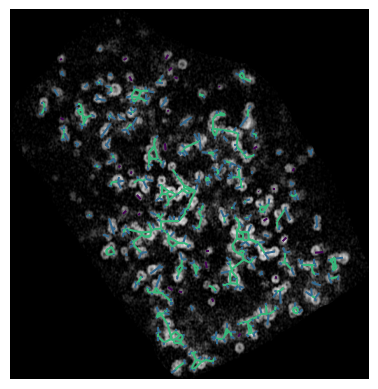

In [23]:
draw.overlay_euclidean_skeleton_2d(equalized_hist[0], branch_data[0],
                                   skeleton_color_source='branch_type')

In [ ]:
skelly = Skeleton(skeletons[0],source_image=equalized_hist[0],spacing=spacing_um)

In [ ]:
fig, ax = plt.subplots()
draw.overlay_skeleton_2d_class(skelly, skeleton_color_source="skeleton_id", axes=ax)

In [5]:
files = sorted(glob("cropped_imgs/*.tif"))
names = [os.path.basename(file) for file in files]

In [9]:
for name,df in zip(names,branch_data):
    df['filename'] = name

merged_df = pd.concat(branch_data)

In [43]:
merged_df.to_csv('Output/skeleton_df.csv')

In [42]:
markdown_table = merged_df[:5]
markdown_table = markdown_table.to_markdown()
print(markdown_table)

|    |   skeleton_id |   node_id_src |   node_id_dst |   branch_distance |   branch_type |   mean_pixel_value |   stdev_pixel_value |   image_coord_src_0 |   image_coord_src_1 |   image_coord_dst_0 |   image_coord_dst_1 |   coord_src_0 |   coord_src_1 |   coord_dst_0 |   coord_dst_1 |   euclidean_distance | filename                                    |
|---:|--------------:|--------------:|--------------:|------------------:|--------------:|-------------------:|--------------------:|--------------------:|--------------------:|--------------------:|--------------------:|--------------:|--------------:|--------------:|--------------:|---------------------:|:--------------------------------------------|
|  0 |             0 |             0 |             2 |         0.168995  |             1 |                255 |                   0 |                  60 |                 142 |                  62 |                 141 |          4.2  |          9.94 |          4.34 |          9.87 |     

In [14]:
import seaborn as sns

<Axes: xlabel='Condition', ylabel='branch distance (um)'>

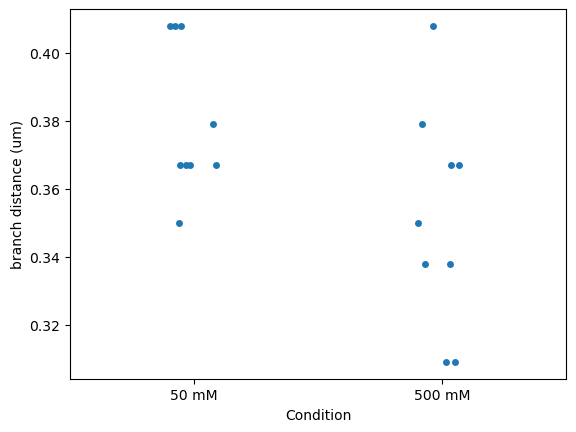

In [29]:
j2j=(merged_df[merged_df['branch_type']== 1].
     rename(columns={'branch_distance':
                     'branch distance (um)'}))
per_image = j2j.groupby('filename').median()
per_image['Condition'] = ['500 mM' if '500mm' in fn else '50 mM' for fn in per_image.index]

sns.stripplot(data=per_image,
              x='Condition',y='branch distance (um)',
              order=['50 mM','500 mM'],
              jitter=True)

In [30]:
per_image.tail()

,skeleton_id,node_id_src,node_id_dst,branch distance (um),branch_type,mean_pixel_value,stdev_pixel_value,image_coord_src_0,image_coord_src_1,image_coord_dst_0,image_coord_dst_1,coord_src_0,coord_src_1,coord_dst_0,coord_dst_1,euclidean_distance,Condition
filename,,,,,,,,,,,,,,,,,
wt_tom20_gfp_day1_50mm_scene3_z30_crop.tif,47.0,3821.0,3931.0,0.366985,1.0,255.0,0.0,381.0,258.0,387.0,261.0,26.670,18.06,27.090,18.27,0.350000,50 mM
wt_tom20_gfp_day1_50mm_scene3_z35_crop.tif,29.0,4662.5,4687.0,0.407990,1.0,255.0,0.0,389.5,275.0,391.5,277.0,27.265,19.25,27.405,19.39,0.376962,50 mM
wt_tom20_gfp_day1_50mm_scene5_z35_crop.tif,30.0,5011.0,5121.0,0.378995,1.0,255.0,0.0,315.0,415.0,319.0,416.0,22.050,29.05,22.330,29.12,0.356931,50 mM
wt_tom20_gfp_day1_50mm_scene5_z40_crop.tif,56.0,4274.0,4450.0,0.407990,1.0,255.0,0.0,315.0,428.0,319.0,428.0,22.050,29.96,22.330,29.96,0.376962,50 mM
wt_tom20_gfp_day1_50mm_scene5_z45_crop.tif,46.0,5900.0,6057.0,0.366985,1.0,255.0,0.0,336.0,419.0,342.0,421.0,23.520,29.33,23.940,29.47,0.350000,50 mM


In [ ]:
# creating summary stats of the skeleton measurements
merged_df.groupby(['filename','skeleton_id'])['branch_distance'].mean()

filename                                     skeleton_id
wt_tom20_gfp_day1_500mm_scene3_z22_crop.tif  0              0.145662
                                             1              0.605980
                                             2              0.436985
                                             3              0.267990
                                             4              2.208944
                                                              ...   
wt_tom20_gfp_day1_50mm_scene5_z45_crop.tif   81             0.460593
                                             82             0.380239
                                             83             0.497320
                                             84             0.520458
                                             85             0.687449
Name: branch_distance, Length: 2139, dtype: float64

In [35]:
summary_df.head()

,skeleton_id,node_id_src,node_id_dst,branch_distance,branch_type,mean_pixel_value,stdev_pixel_value,image_coord_src_0,image_coord_src_1,image_coord_dst_0,image_coord_dst_1,coord_src_0,coord_src_1,coord_dst_0,coord_dst_1,euclidean_distance,filename
0,0,0,2,0.168995,1,255.0,0.0,60,142,62,141,4.20,9.94,4.34,9.87,0.156525,wt_tom20_gfp_day1_500mm_scene3_z22_crop.tif
1,0,2,3,0.168995,1,255.0,0.0,62,141,63,139,4.34,9.87,4.41,9.73,0.156525,wt_tom20_gfp_day1_500mm_scene3_z22_crop.tif
2,0,2,5,0.098995,1,255.0,0.0,62,141,63,142,4.34,9.87,4.41,9.94,0.098995,wt_tom20_gfp_day1_500mm_scene3_z22_crop.tif
3,1,6,19,0.605980,0,255.0,0.0,71,248,78,244,4.97,17.36,5.46,17.08,0.564358,wt_tom20_gfp_day1_500mm_scene3_z22_crop.tif
4,2,11,22,0.436985,0,255.0,0.0,76,183,79,178,5.32,12.81,5.53,12.46,0.408167,wt_tom20_gfp_day1_500mm_scene3_z22_crop.tif
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1784,84,11764,11792,0.366985,1,255.0,0.0,644,608,648,611,45.08,42.56,45.36,42.77,0.350000,wt_tom20_gfp_day1_50mm_scene5_z45_crop.tif
1785,85,11769,11791,0.436985,1,255.0,0.0,644,668,647,663,45.08,46.76,45.29,46.41,0.408167,wt_tom20_gfp_day1_50mm_scene5_z45_crop.tif
1786,85,11778,11781,0.210000,2,255.0,0.0,646,655,646,658,45.22,45.85,45.22,46.06,0.210000,wt_tom20_gfp_day1_50mm_scene5_z45_crop.tif
1787,85,11781,11791,0.378995,2,255.0,0.0,646,658,647,663,45.22,46.06,45.29,46.41,0.356931,wt_tom20_gfp_day1_50mm_scene5_z45_crop.tif
